# Down and Out Barrier Option
The derivative pricing is calculated based on Black Sholes assumption of constant volatility and interest rate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

seed = 123
rng = np.random.default_rng(seed)

In [16]:
def call_payoff(S_T, K):
    return np.maximum(S_T - K, 0)

def put_payoff(S_T, K):
    return np.maximum(K - S_T, 0)

Simulate price paths with euler:

In [17]:
# The Euler discretization simulates the price path step by step
def euler_discretization(S0, r, sigma, T, dt, rng):
    N = int(T/dt)  # number of time steps
    times = np.linspace(0, T, N+1)
    S = {times[0]: S0}
    
    for t in range(1, N+1):
        error = rng.standard_normal()  # generate standard normal random variables
        S[times[t]] = S[times[t-1]] *(1 + r * dt + sigma * np.sqrt(dt) * error)
    return S

In [18]:
S0 = 100  # initial stock price
K = 100   # strike price for call option
r = 0.05  # risk-free interest rate
T = 1.0   # time to maturity in years
sigma = 0.2  # volatility
n_simulations = 10000 # number of Monte Carlo simulations
dt = 0.01  # time step for Euler discretization
down_and_out = 85
down_and_in = 85


# Call

In [19]:
payoffs_in = {'call': [], 'put': []}
payoffs_out = {'call': [], 'put': []}
S_paths = []
for _ in range(n_simulations):
    S_path = euler_discretization(S0, r, sigma, T, dt, rng)
    S_paths.append(S_path)
    S_T = list(S_path.values())[-1]
    if min(S_path.values()) > down_and_out:
        payoffs_out['call'].append(call_payoff(S_T, K))
        payoffs_out['put'].append(put_payoff(S_T, K))
    else:
        payoffs_out['call'].append(0)
        payoffs_out['put'].append(0)
    if min(S_path.values()) < down_and_in:
        payoffs_in['call'].append(call_payoff(S_T, K))
        payoffs_in['put'].append(put_payoff(S_T, K))
    else:
        payoffs_in['call'].append(0)
        payoffs_in['put'].append(0)
call_option_price_out = np.exp(-r * T) * np.mean(payoffs_out['call'])
call_option_price_in = np.exp(-r * T) * np.mean(payoffs_in['call'])
put_option_price_out = np.exp(-r * T) * np.mean(payoffs_out['put'])
put_option_price_in = np.exp(-r * T) * np.mean(payoffs_in['put'])

print(f"Estimated price of the down-and-in barrier put option: {put_option_price_in:.2f}")
print(f"Estimated price of the down-and-in barrier call option: {call_option_price_in:.2f}")

print(f"Estimated price of the down-and-out barrier call option: {call_option_price_out:.2f}")
print(f"Estimated price of the down-and-out barrier put option: {put_option_price_out:.2f}")


Estimated price of the down-and-in barrier put option: 4.75
Estimated price of the down-and-in barrier call option: 0.39
Estimated price of the down-and-out barrier call option: 10.15
Estimated price of the down-and-out barrier put option: 0.78


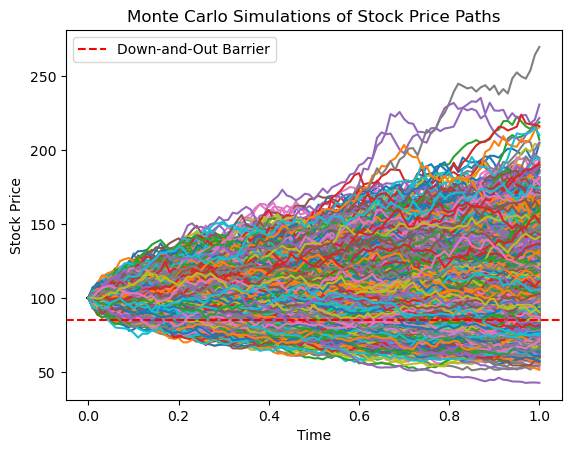

In [20]:
for path in S_paths:
    times = list(path.keys())
    prices = list(path.values())
    plt.plot(times, prices)
plt.axhline(y=down_and_out, color='r', linestyle='--', label='Down-and-Out Barrier')
plt.legend()
plt.title('Monte Carlo Simulations of Stock Price Paths')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.show()